# **Saudi Stock Market Data Preparation Pipeline**
***Risk-Adjusted Sector Analysis Framework (2020–2026)***

This script serves as the primary data preparation workflow for the Saudi stock market sector analysis project.
Its purpose is to transform raw historical trading data into a validated, structured, and analysis-ready dataset
while preserving full compatibility with the Tableau dashboard layer.

**The pipeline follows a disciplined and reproducible approach that includes:**

1. Data Loading and Structural Inspection  
2. Data Type Standardization  
3. Core Data Cleaning (Missing Values & Duplicates)  
4. Logical Price Validation  
5. Exploratory Sanity Checks  
6. Feature Engineering (Daily Returns & Time Components)  
7. Visual Validation (Pre-Export Analysis Only)  
8. Final Structuring and Export  

The objective of this workflow is not to alter the business structure of the data, but to ensure logical integrity,
statistical reliability, and analytical readiness before visualization and sector-level modeling.


This exported dataset acts as the single source of truth for dashboard construction and sector performance evaluation.


# **1. Data Loading**


The first step is to load the raw dataset into the environment.
At this stage, no transformations are applied. The goal is simply to read the file and confirm that the dataset has been imported correctly before moving to cleaning or validation.


In [19]:
import pandas as pd

# Load raw dataset from Colab directory
df = pd.read_csv("/content/historical_data.csv")

# Basic structural inspection
print("Initial shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Initial shape: (21818, 9)
Columns: ['date', 'ticker', 'company', 'sector', 'open', 'high', 'low', 'close', 'volume']

First 5 rows:
       date   ticker     company   sector       open       high        low  \
0  1/1/2020  1010.SR  Riyad Bank  Banking  19.042840  19.058697  18.773290   
1  1/2/2020  1010.SR  Riyad Bank  Banking  19.026987  19.137976  19.011130   
2  1/5/2020  1010.SR  Riyad Bank  Banking  18.234198  18.963566  18.234198   
3  1/6/2020  1010.SR  Riyad Bank  Banking  18.789146  19.026983  18.789146   
4  1/7/2020  1010.SR  Riyad Bank  Banking  19.026985  19.328245  19.026985   

       close   volume  
0  18.947704   217707  
1  19.122122   639484  
2  18.741583   658944  
3  18.947704  1375266  
4  19.280678   972061  


# **2. Data Type Standardization**
After loading the dataset, the next step is to ensure that all columns have the correct data types.
The date column must be converted into a proper datetime format so it can be used for time-based analysis.
Price and volume columns must be converted to numeric values to prevent calculation errors later when computing returns and volatility.
This step does not change the structure of the dataset it only ensures type consistency.

In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

numeric_cols = ['open','high','low','close','volume']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# **3. Data Cleaning  Missing Values & Duplicates**
At this stage, the dataset is cleaned from structurally invalid records.
Only critical columns are considered when removing missing values, specifically those required for price calculations and sector-level analysis. Rows missing essential fields such as date, prices, volume, or sector are removed to ensure analytical integrity.
Duplicate rows are also eliminated to prevent distortion in aggregation, return calculations, or sector-level metrics.
This step ensures the dataset remains reliable while preserving its overall structure.

In [6]:
df = df.dropna(subset=['date','open','high','low','close','volume','sector'])

df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (21818, 9)


# **4. Logical Price Validation**
After removing missing values and duplicates, the dataset undergoes logical validation to ensure price consistency. Financial market data must follow realistic trading behavior, meaning that the recorded low price should not exceed the open or close, and the high price should not fall below them. Additionally, negative price or volume values are not valid in this context. Any rows violating these logical conditions are removed to preserve the integrity of return calculations and volatility analysis while keeping the overall dataset structure unchanged.

In [7]:
# Logical price validation
price_logic_issues = df[
    (df['low'] > df['open']) |
    (df['low'] > df['close']) |
    (df['high'] < df['open']) |
    (df['high'] < df['close'])
]

print("Price logic issues:", len(price_logic_issues))

df = df.drop(price_logic_issues.index)

# Negative value validation
negative_values = df[
    (df['open'] < 0) |
    (df['high'] < 0) |
    (df['low'] < 0) |
    (df['close'] < 0) |
    (df['volume'] < 0)
]

print("Negative value issues:", len(negative_values))

df = df.drop(negative_values.index)

print("Shape after logical validation:", df.shape)

Price logic issues: 6
Negative value issues: 0
Shape after logical validation: (21812, 9)


# **5. Exploratory Data Review**
Before moving into feature engineering, a brief exploratory review is performed to validate overall dataset consistency. This step confirms the date range coverage, sector distribution, and general price behavior. The purpose here is not transformation, but reassurance that the cleaned dataset reflects realistic market structure and sufficient sector representation for reliable comparative analysis.

In [8]:
print("\nDate Range:")
print("Start:", df['date'].min())
print("End:", df['date'].max())

print("\nSector Distribution:")
print(df['sector'].value_counts())

print("\nPrice Summary Statistics:")
print(df[['open','high','low','close','volume']].describe())


Date Range:
Start: 2020-01-01 00:00:00
End: 2026-01-15 00:00:00

Sector Distribution:
sector
Banking                         4525
Basic Materials                 3774
Insurance                       3015
Financial Services              2530
Energy                          1510
Telecommunications              1508
Food Production                 1507
Healthcare                      1452
Utilities                       1018
IT Applications and Services     973
Name: count, dtype: int64

Price Summary Statistics:
               open          high           low         close        volume
count  21812.000000  21812.000000  21812.000000  21812.000000  2.181200e+04
mean     113.370470    114.795384    112.012423    113.354130  2.157451e+06
std      162.432060    164.747971    160.316248    162.388561  7.714779e+06
min        4.669193      4.880689      4.669193      4.799345  0.000000e+00
25%       31.704374     31.971863     31.376169     31.700022  1.602478e+05
50%       57.174860     57.

# **6. Feature Engineering  Daily Return & Time Components**

With the dataset validated, derived features are created to support performance and volatility analysis. Daily return is calculated for each ticker using percentage change in closing prices. The data is first sorted to ensure chronological consistency within each ticker. Additionally, year, month, and quarter fields are extracted from the date column to enable time-based aggregation in the dashboard. These additions do not alter the dataset structure required by Tableau but enhance analytical flexibility.

In [9]:
df = df.sort_values(['ticker','date'])

df['daily_return'] = (
    df.groupby('ticker')['close']
    .pct_change()
    .fillna(0)
)

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

print("Shape after feature engineering:", df.shape)
print("\nDaily Return Summary:")
print(df['daily_return'].describe())

Shape after feature engineering: (21812, 13)

Daily Return Summary:
count    21812.000000
mean         0.000639
std          0.018381
min         -0.341695
25%         -0.007830
50%          0.000000
75%          0.007990
max          0.510911
Name: daily_return, dtype: float64


# **6.5 Visual Validation (Pre-Export Analysis Only)**

Before exporting the final dataset, a preliminary visual validation step is conducted to ensure that return distributions and sector-level dispersion behave as expected. These visualizations are used strictly for internal analytical verification and do not alter the dataset structure or exported schema. Their purpose is to confirm statistical stability and detect any abnormal distortions prior to dashboard integration.

**Daily Return Distribution**

This visualization confirms that daily returns follow a reasonable distribution pattern and do not exhibit extreme structural anomalies.

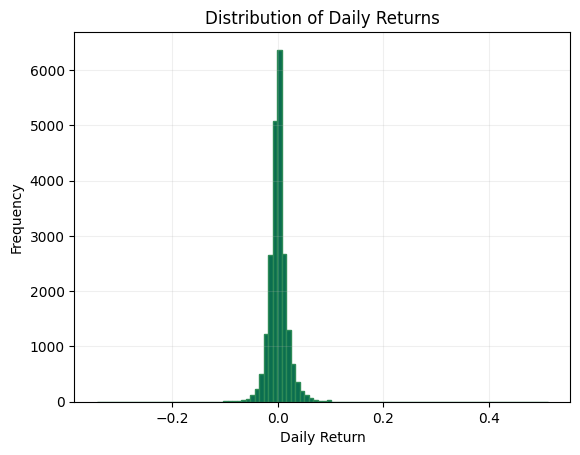

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.hist(
    df['daily_return'],
    bins=100,
    color="#0B6E4F",
    edgecolor="#2E8B57"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)
plt.show()

# Sector Volatility Comparison

This chart validates dispersion differences across sectors and confirms that no single sector exhibits unrealistic volatility spikes.

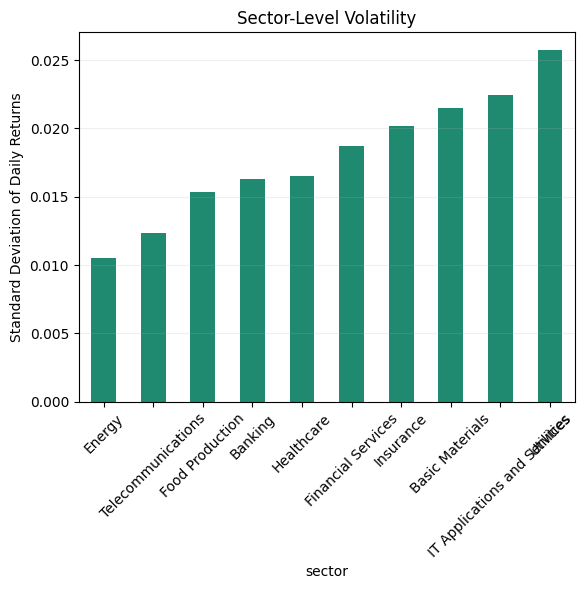

In [14]:
sector_volatility = df.groupby('sector')['daily_return'].std().sort_values()

plt.figure()

sector_volatility.plot(
    kind='bar',
    color="#1F8A70"
)

plt.title("Sector-Level Volatility")
plt.ylabel("Standard Deviation of Daily Returns")
plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.2)
plt.show()

**Risk vs Return Scatter (Preliminary Check)**

This scatterplot provides a quick sanity check of return-risk positioning before final dashboard modeling.

/tmp/ipython-input-2813417850.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sector_stats['std'][i],
/tmp/ipython-input-2813417850.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sector_stats['mean'][i],


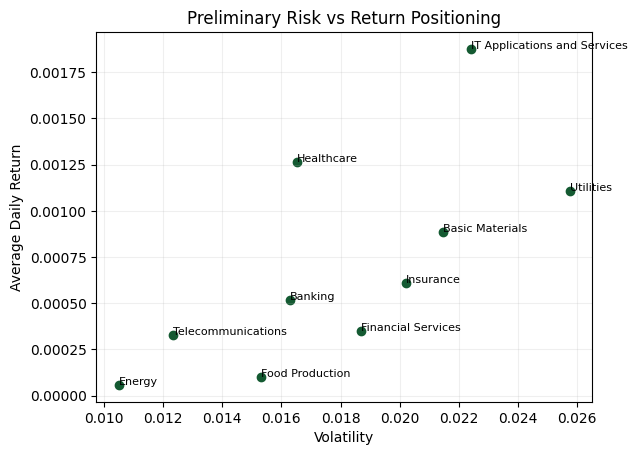

In [15]:
sector_stats = df.groupby('sector')['daily_return'].agg(['mean','std'])

plt.figure()

plt.scatter(
    sector_stats['std'],
    sector_stats['mean'],
    color="#145A32"   # Deep green
)

for i, sector in enumerate(sector_stats.index):
    plt.text(
        sector_stats['std'][i],
        sector_stats['mean'][i],
        sector,
        fontsize=8
    )

plt.xlabel("Volatility")
plt.ylabel("Average Daily Return")
plt.title("Preliminary Risk vs Return Positioning")

plt.grid(alpha=0.2)
plt.show()

These visual checks are conducted solely for internal validation prior to dataset export. They do not introduce structural changes, additional features, or modifications to the final Tableau-ready dataset.

# **7. Final Structuring & Export**

After completing data validation, feature engineering, and preliminary visual checks, the dataset is finalized for dashboard integration. At this stage, the column structure is explicitly reordered to match the schema expected by the Tableau dashboard. No additional fields are introduced, and no structural modifications are made beyond formatting. The cleaned and engineered dataset is then exported as a production-ready CSV file for visualization and sector-level analysis.

In [17]:
df = df[['date','year','quarter','month',
         'ticker','company','sector',
         'open','high','low','close',
         'volume','daily_return']]

df.to_csv("/content/saudi_market_prepared.csv", index=False)

print("\nFinal shape:", df.shape)
print("\nMissing values check:\n", df.isnull().sum())

assert df.isnull().sum().sum() == 0, "Dataset still contains missing values"


Final shape: (21812, 13)

Missing values check:
 date            0
year            0
quarter         0
month           0
ticker          0
company         0
sector          0
open            0
high            0
low             0
close           0
volume          0
daily_return    0
dtype: int64
